In [ ]:
# ==========================================
# CELL 1 — Install Required Libraries
# ==========================================

!pip install kagglehub opencv-python scikit-image -q

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from skimage.feature import local_binary_pattern

In [ ]:
# ==========================================
# CELL 2 — Download Dataset Directly
# from Kaggle URL
# ==========================================

# Directly downloads dataset from Kaggle
path = kagglehub.dataset_download(
    "lazrus/indian-coin-denomination-dataset-icdd"
)

print("Dataset Path :", path)

100%|██████████| 3.42G/3.42G [00:35<00:00, 103MB/s]

Extracting files...


Dataset Path : /root/.cache/kagglehub/datasets/lazrus/indian-coin-denomination-dataset-icdd/versions/1


In [ ]:
# ==========================================
# CELL 3 — Final Correct Dataset Path
# ==========================================

dataset_path = os.path.join(path, "DataSet")

print("Folders Found :")

print(os.listdir(dataset_path))

Folders Found :
['One', 'Five', 'Ten', 'Two', 'Twenty']


In [ ]:
# ==========================================
# CHECK FOLDER STRUCTURE
# ==========================================

for cls in ['One', 'Two', 'Five', 'Ten', 'Twenty']:

    folder = os.path.join(dataset_path, cls)

    print(f"\nCLASS : {cls}")

    print(os.listdir(folder)[:10])


CLASS : One
['Coin 4', 'Coin 1', 'Coin 5', 'Coin 6', 'Coin 2', 'Coin 3', 'Coin 7']

CLASS : Two
['Coin 4', 'Coin 1', 'Coin 2', 'Coin 3']

CLASS : Five
['Coin 4', 'Coin 1', 'Coin 5', 'Coin 9', 'Coin 6', 'Coin 8', 'Coin 2', 'Coin 3', 'Coin 7']

CLASS : Ten
['Coin 4', 'Coin 1', 'Coin 5', 'Coin 6', 'Coin 2', 'Coin 3']

CLASS : Twenty
['Coin 4', 'Coin 1', 'Coin 2', 'Coin 3']


In [ ]:
# ==========================================
# CHECK FINAL IMAGE LOCATION
# ==========================================

sample_folder = os.path.join(dataset_path, "One", "Coin 1")

print(os.listdir(sample_folder)[:20])

['Artificial Light', 'Low Light', 'Natural Light']


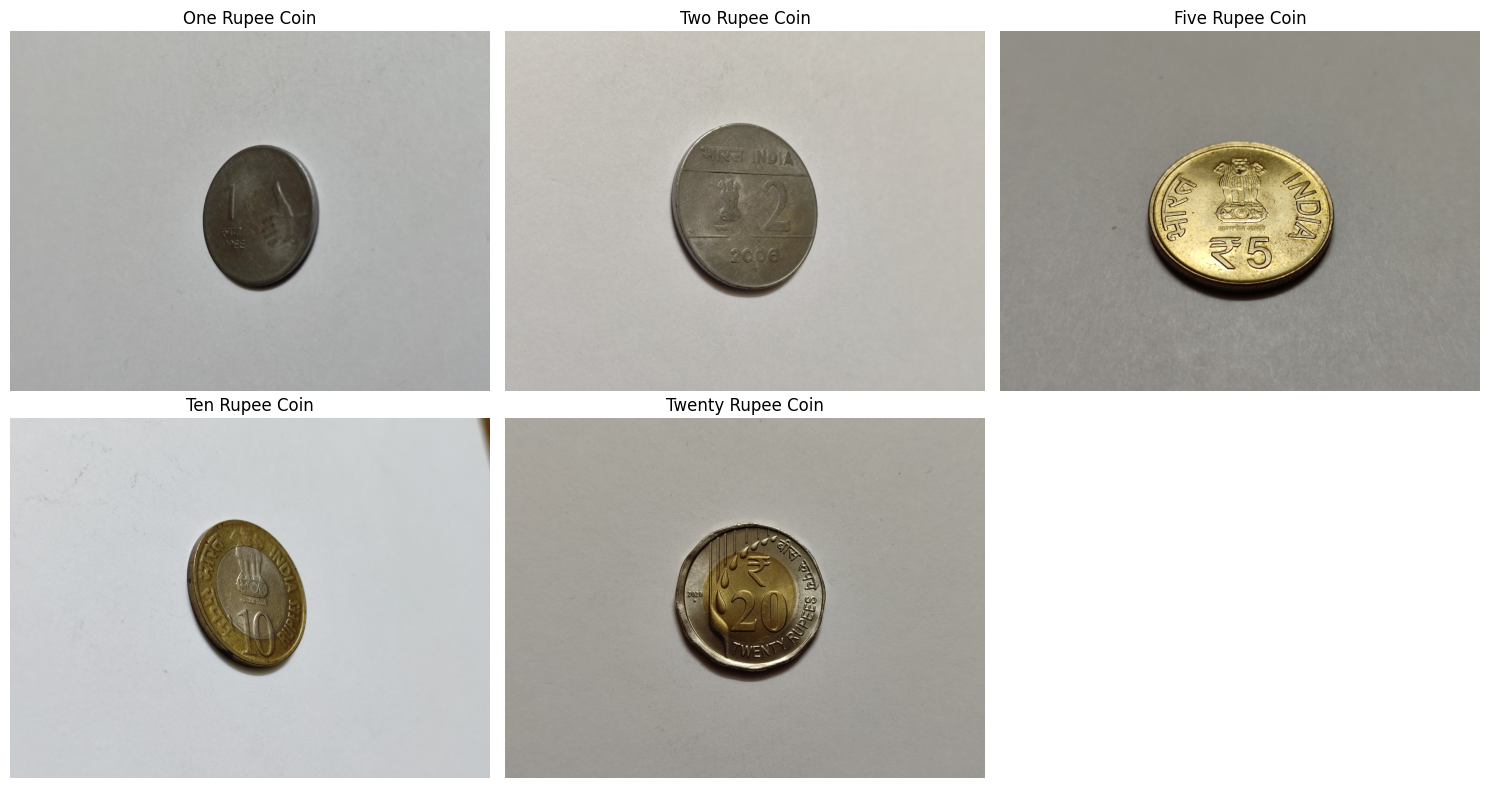

  Denomination  Image_Count
0          One          210
1          Two          120
2         Five          270
3          Ten          180
4       Twenty          120

Total Images : 900


In [ ]:
# ==========================================
# CELL 4 — FINAL WORKING EDA
# ==========================================

classes = ['One', 'Two', 'Five', 'Ten', 'Twenty']

image_count = []

available_classes = []

widths = []

heights = []

brightness_values = []

edge_density = []

plt.figure(figsize=(15,8))

count = 1

for cls in classes:

    class_folder = os.path.join(dataset_path, cls)

    all_images = []

    # ======================================
    # Traverse all nested folders
    # ======================================

    for root, dirs, files in os.walk(class_folder):

        for file in files:

            if file.lower().endswith(
                ('.png', '.jpg', '.jpeg')
            ):

                all_images.append(
                    os.path.join(root, file)
                )

    if len(all_images) == 0:

        print(f"No images found in {cls}")

        continue

    available_classes.append(cls)

    image_count.append(len(all_images))

    # ======================================
    # Sample Image
    # ======================================

    sample = cv2.imread(all_images[0])

    if sample is None:
        continue

    sample_rgb = cv2.cvtColor(
        sample,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(2,3,count)

    plt.imshow(sample_rgb)

    plt.title(f"{cls} Rupee Coin")

    plt.axis('off')

    count += 1

    # ======================================
    # Analysis Loop
    # ======================================

    for img_path in all_images:

        img = cv2.imread(img_path)

        if img is None:
            continue

        # Image Dimensions
        h, w = img.shape[:2]

        widths.append(w)

        heights.append(h)

        # ==================================
        # Brightness Analysis
        # ==================================

        hsv = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2HSV
        )

        brightness_values.append(
            hsv[:,:,2].mean()
        )

        # ==================================
        # Edge Density Analysis
        # ==================================

        gray = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2GRAY
        )

        edges = cv2.Canny(
            gray,
            100,
            200
        )

        density = np.sum(edges > 0) / edges.size

        edge_density.append(density)

# ==========================================
# Show Sample Images
# ==========================================

plt.tight_layout()

plt.show()

# ==========================================
# Dataset Summary
# ==========================================

summary = pd.DataFrame({
    "Denomination": available_classes,
    "Image_Count": image_count
})

print(summary)

print("\nTotal Images :", sum(image_count))

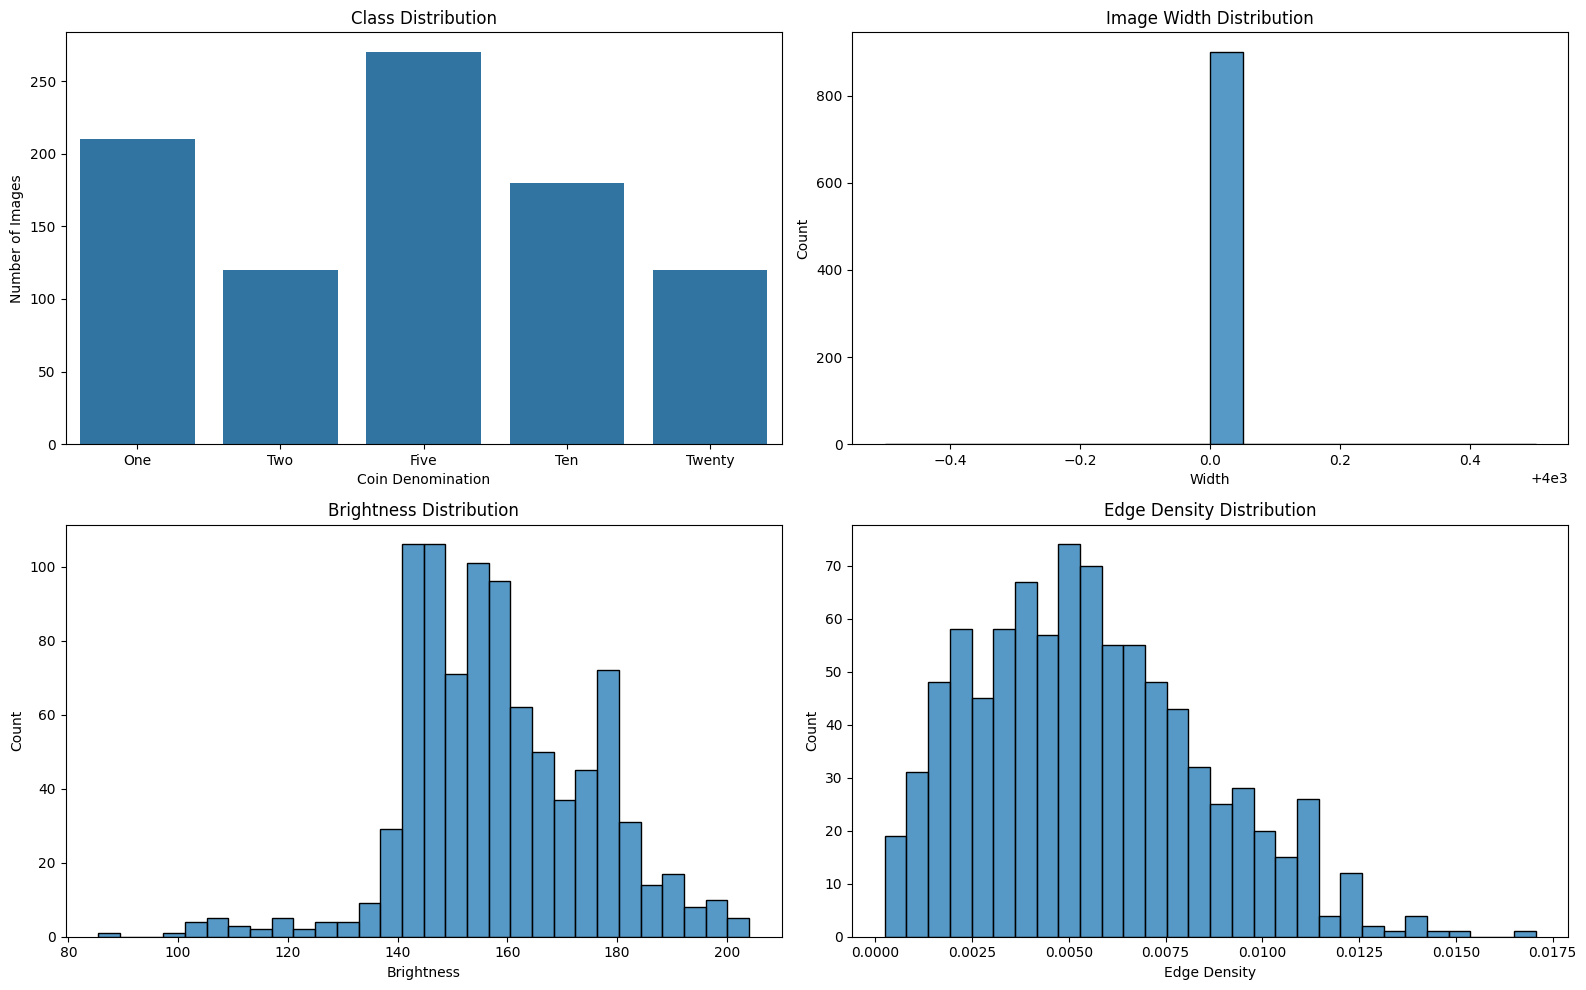

In [ ]:
# ==========================================
# CELL 5 — EDA Visualizations
# ==========================================

plt.figure(figsize=(16,10))

# ======================================
# 1. Class Distribution
# ======================================

plt.subplot(2,2,1)

sns.barplot(
    x=available_classes,
    y=image_count
)

plt.title("Class Distribution")

plt.xlabel("Coin Denomination")

plt.ylabel("Number of Images")

# ======================================
# 2. Image Width Distribution
# ======================================

plt.subplot(2,2,2)

sns.histplot(
    widths,
    bins=20
)

plt.title("Image Width Distribution")

plt.xlabel("Width")

# ======================================
# 3. Brightness Distribution
# ======================================

plt.subplot(2,2,3)

sns.histplot(
    brightness_values,
    bins=30
)

plt.title("Brightness Distribution")

plt.xlabel("Brightness")

# ======================================
# 4. Edge Density Distribution
# ======================================

plt.subplot(2,2,4)

sns.histplot(
    edge_density,
    bins=30
)

plt.title("Edge Density Distribution")

plt.xlabel("Edge Density")

plt.tight_layout()

plt.show()

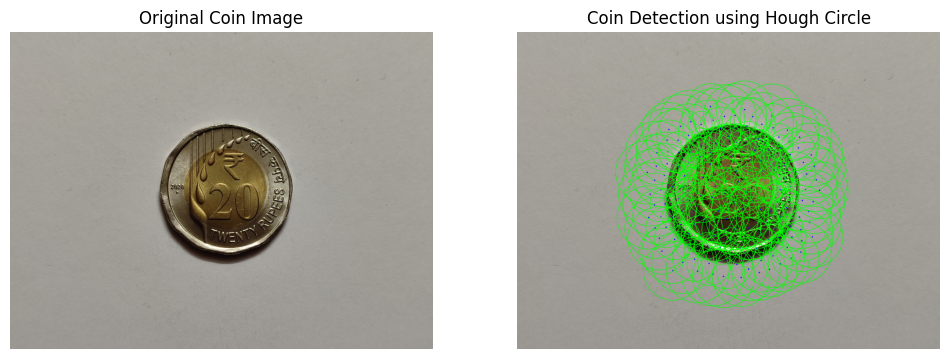

In [ ]:
# ==========================================
# CELL 6 — Hough Circle Detection
# ==========================================

# Take one sample image
sample_image = all_images[0]

img = cv2.imread(sample_image)

output = img.copy()

gray = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2GRAY
)

# Reduce noise
gray_blur = cv2.medianBlur(gray, 5)

# ======================================
# Hough Circle Transform
# ======================================

circles = cv2.HoughCircles(
    gray_blur,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=100,
    param1=50,
    param2=30,
    minRadius=50,
    maxRadius=300
)

# Draw circles
if circles is not None:

    circles = np.round(
        circles[0, :]
    ).astype("int")

    for (x, y, r) in circles:

        # Outer circle
        cv2.circle(
            output,
            (x, y),
            r,
            (0,255,0),
            3
        )

        # Center point
        cv2.rectangle(
            output,
            (x-5, y-5),
            (x+5, y+5),
            (255,0,0),
            -1
        )

# ======================================
# Display Results
# ======================================

plt.figure(figsize=(12,6))

# Original Image
plt.subplot(1,2,1)

plt.imshow(
    cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
)

plt.title("Original Coin Image")

plt.axis('off')

# Detected Circle
plt.subplot(1,2,2)

plt.imshow(
    cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
)

plt.title("Coin Detection using Hough Circle")

plt.axis('off')

plt.show()

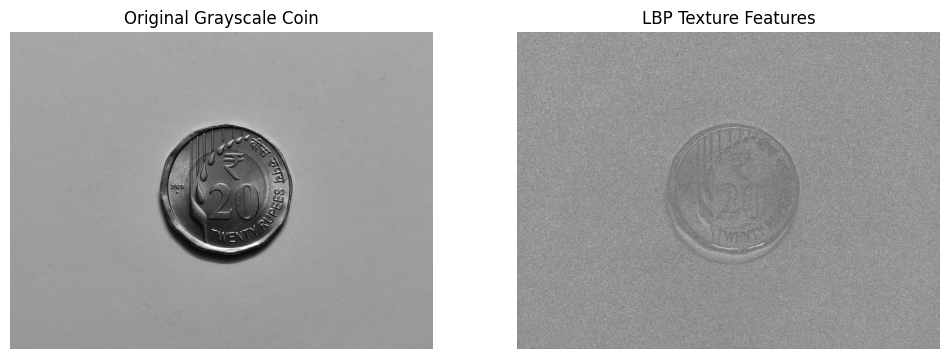

In [ ]:
# ==========================================
# CELL 7 — LBP Texture Analysis
# ==========================================

from skimage.feature import local_binary_pattern

# ======================================
# Convert to Grayscale
# ======================================

gray = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2GRAY
)

# ======================================
# LBP Feature Extraction
# ======================================

lbp = local_binary_pattern(
    gray,
    P=8,
    R=1,
    method='uniform'
)

# ======================================
# Display Results
# ======================================

plt.figure(figsize=(12,5))

# Original Image
plt.subplot(1,2,1)

plt.imshow(gray, cmap='gray')

plt.title("Original Grayscale Coin")

plt.axis('off')

# LBP Texture Image
plt.subplot(1,2,2)

plt.imshow(lbp, cmap='gray')

plt.title("LBP Texture Features")

plt.axis('off')

plt.show()

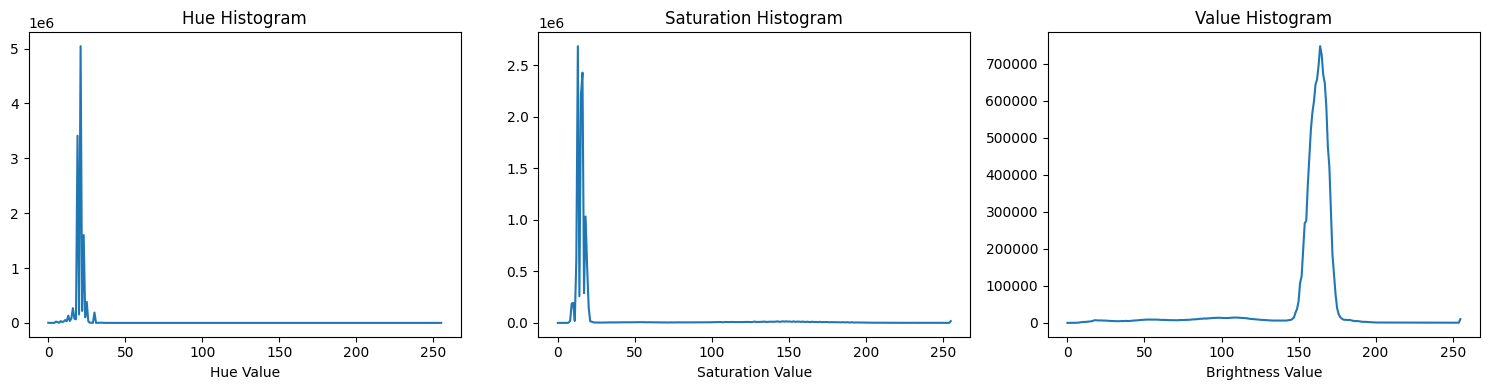

In [ ]:
# ==========================================
# CELL 8 — HSV Color Histogram Analysis
# ==========================================

# ======================================
# Convert Image to HSV
# ======================================

hsv = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2HSV
)

# ======================================
# Calculate Histograms
# ======================================

h_hist = cv2.calcHist(
    [hsv],
    [0],
    None,
    [256],
    [0,256]
)

s_hist = cv2.calcHist(
    [hsv],
    [1],
    None,
    [256],
    [0,256]
)

v_hist = cv2.calcHist(
    [hsv],
    [2],
    None,
    [256],
    [0,256]
)

# ======================================
# Plot Histograms
# ======================================

plt.figure(figsize=(15,4))

# Hue Histogram
plt.subplot(1,3,1)

plt.plot(h_hist)

plt.title("Hue Histogram")

plt.xlabel("Hue Value")

# Saturation Histogram
plt.subplot(1,3,2)

plt.plot(s_hist)

plt.title("Saturation Histogram")

plt.xlabel("Saturation Value")

# Value Histogram
plt.subplot(1,3,3)

plt.plot(v_hist)

plt.title("Value Histogram")

plt.xlabel("Brightness Value")

plt.tight_layout()

plt.show()

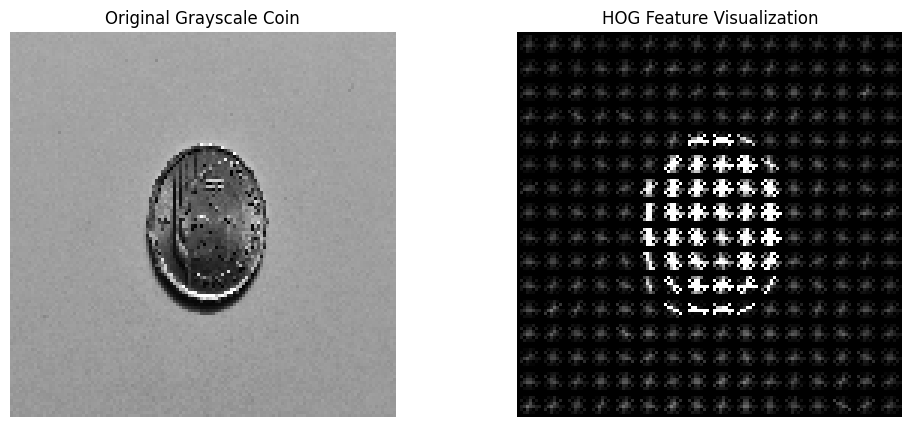

HOG Feature Vector Length : 8100


In [ ]:
# ==========================================
# CELL 9 — HOG Feature Visualization
# ==========================================

from skimage.feature import hog
from skimage import exposure

# ======================================
# Convert to Grayscale
# ======================================

gray = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2GRAY
)

# Resize image for HOG
gray_resized = cv2.resize(
    gray,
    (128,128)
)

# ======================================
# Extract HOG Features
# ======================================

hog_features, hog_image = hog(
    gray_resized,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True
)

# Improve visibility
hog_image_rescaled = exposure.rescale_intensity(
    hog_image,
    in_range=(0,10)
)

# ======================================
# Display Results
# ======================================

plt.figure(figsize=(12,5))

# Original Image
plt.subplot(1,2,1)

plt.imshow(gray_resized, cmap='gray')

plt.title("Original Grayscale Coin")

plt.axis('off')

# HOG Visualization
plt.subplot(1,2,2)

plt.imshow(hog_image_rescaled, cmap='gray')

plt.title("HOG Feature Visualization")

plt.axis('off')

plt.show()

print("HOG Feature Vector Length :", len(hog_features))